In [35]:
import pandas as pd 
import seaborn as sns 
import matplotlib as plt 
from imblearn.over_sampling import SMOTE

In [29]:
df=pd.read_csv(r"C:\Users\hp\Downloads\FinalEdit.csv")
data_size=df.shape
print(data_size)
print(df.dtypes)
#print(df.columns)
target ="label" # is better to name it x for ML ?
features= df.columns[df.columns != target ]



(149098, 10)
channel             object
start_time         float64
stop_time          float64
label               object
confidence           int64
bname               object
patient_id          object
session_id          object
trial_id            object
patient_session     object
dtype: object


In [12]:
missing_values_sum=df.isnull().sum()
percentage1=df.isnull().mean()*100

print(missing_values_sum)
print(percentage1) 

#no need for imputation or removal

channel            0
start_time         0
stop_time          0
label              0
confidence         0
bname              0
patient_id         0
session_id         0
trial_id           0
patient_session    0
dtype: int64
channel            0.0
start_time         0.0
stop_time          0.0
label              0.0
confidence         0.0
bname              0.0
patient_id         0.0
session_id         0.0
trial_id           0.0
patient_session    0.0
dtype: float64


          start_time      stop_time  confidence
count  149098.000000  149098.000000    149098.0
mean      178.355744     559.472086         1.0
std       419.384590     503.785226         0.0
min         0.000000       0.749000         1.0
25%         0.000000     272.082100         1.0
50%         0.000000     435.000000         1.0
75%       160.997300     624.624000         1.0
max      5754.029500    5824.625800         1.0
label
bckg    0.821634
fnsz    0.086681
gnsz    0.050772
cpsz    0.020134
absz    0.007371
spsz    0.006318
tcsz    0.004246
tnsz    0.002549
mysz    0.000295
Name: proportion, dtype: float64


<Axes: xlabel='label', ylabel='count'>

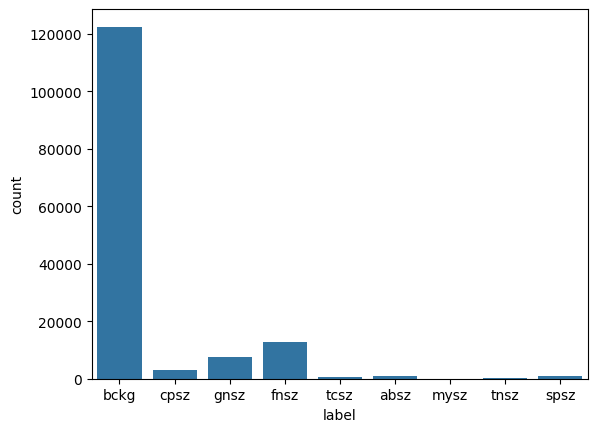

In [ ]:
descriptive_statistics=df.describe()
print(descriptive_statistics)

#distribution of label only
rate=df['label'].value_counts(normalize=True)
print(rate)

#visualize 
sns.countplot(x='label', data=df)

In [ ]:
# distribution of features 
sns.boxplot(x=features, data=df) 

In [ ]:
#relationship
sns.violinplot(x=target, y=features, data=df)

In [38]:
#test if imbalanced 

x=df.drop("label", axis=1)
y=df['label']
smote=SMOTE(sampling_strategy='minority')
x_balanced,y_balanced =smote.fit_resample(x,y)

counts=y_balanced.value_counts()
plt.bar(counts.index, counts.values)
plt.xlabel('detection of seizure')
plt.ylabel('counts')

plt.xticks(counts.index, ['label'])
plt.show()


ValueError: could not convert string to float: 'FP1-F7'